# 05 — Evaluation

ROC/AUC, γ heatmap, UMAPs of saved embeddings.


In [1]:
USE_DRIVE = True
from pathlib import Path
if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    DATA_DIR = Path("/content/drive/MyDrive/BulkCellGNN_data")
else:
    DATA_DIR = Path.cwd() / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)
print("DATA_DIR =", DATA_DIR.resolve())


Mounted at /content/drive
DATA_DIR = /content/drive/MyDrive/BulkCellGNN_data


In [2]:
import sys, subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torch", "torch_geometric", "matplotlib", "scikit-learn", "umap-learn"])


0

In [3]:
import sys
sys.path.insert(0, '/content/drive/MyDrive/BulkCellGNN_data')

In [4]:
import os, random, sys, json
from pathlib import Path

SEED = 42
random.seed(SEED)
os.environ.setdefault("PYTHONHASHSEED", str(SEED))
import numpy as np
np.random.seed(SEED)
import torch
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, roc_auc_score
import umap

import bulkcell_gnn as bcg

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [6]:
bulk_x = torch.tensor(np.load(DATA_DIR / "bulk_expr_sym.npy"), dtype=torch.float32).to(device)
cell_x = torch.tensor(np.load(DATA_DIR / "cell_expr.npy"), dtype=torch.float32).to(device)
labels = torch.tensor(np.load(DATA_DIR / "bulk_labels.npy"), dtype=torch.long).to(device)
cell_types = torch.tensor(np.load(DATA_DIR / "cell_types.npy"), dtype=torch.long).to(device)
edge_BB = torch.load(DATA_DIR / "edge_BB.pt", map_location=device)
edge_CC = torch.load(DATA_DIR / "edge_CC.pt", map_location=device)
edge_BC = torch.load(DATA_DIR / "edge_BC.pt", map_location=device)
type_names = json.loads((DATA_DIR / "cell_type_names.json").read_text(encoding="utf-8"))

hB = torch.load(DATA_DIR / "hB_final.pt", map_location="cpu").numpy()
hC = torch.load(DATA_DIR / "hC_final.pt", map_location="cpu").numpy()

model = bcg.BulkCellGNN(
    n_bulk_genes=bulk_x.shape[1],
    n_cell_genes=cell_x.shape[1],
    d_latent=256,
    n_classes=2,
    n_cell_types=len(type_names),
    n_layers=2,
    dropout=0.3,
    cell_type_names=type_names,
).to(device)
model.load_state_dict(torch.load(DATA_DIR / "model_best.pt", map_location=device))
model.eval()


BulkCellGNN(
  (bulk_encoder): BulkEncoder(
    (net): Sequential(
      (0): Linear(in_features=22880, out_features=512, bias=True)
      (1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (2): GELU(approximate='none')
      (3): Dropout(p=0.3, inplace=False)
      (4): Linear(in_features=512, out_features=256, bias=True)
      (5): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    )
  )
  (cell_encoder): CellEncoder(
    (net): Sequential(
      (0): Linear(in_features=19545, out_features=512, bias=True)
      (1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (2): GELU(approximate='none')
      (3): Dropout(p=0.3, inplace=False)
      (4): Linear(in_features=512, out_features=256, bias=True)
      (5): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (6): GELU(approximate='none')
      (7): Dropout(p=0.3, inplace=False)
      (8): Linear(in_features=256, out_features=256, bias=True)
      (9): LayerNorm((256,), eps=1e-05, elementwise_af

In [7]:
# ROC on validation bulk (same masks as training notebook if present)
vm_path = DATA_DIR / "val_mask.npy"
if vm_path.exists():
    val_mask = torch.tensor(np.load(vm_path), dtype=torch.bool)
else:
    from sklearn.model_selection import train_test_split
    n_bulk = bulk_x.shape[0]
    idx = np.arange(n_bulk)
    _, va_idx = train_test_split(idx, test_size=0.2, stratify=labels.cpu().numpy(), random_state=SEED)
    val_mask = torch.zeros(n_bulk, dtype=torch.bool)
    val_mask[va_idx] = True

with torch.no_grad():
    out = model(bulk_x, cell_x, edge_BB, edge_CC, edge_BC, cell_types, return_gamma=True)
probs = torch.softmax(out["logits"][val_mask.to(device)], dim=-1)[:, 1].detach().cpu().numpy()
y = labels[val_mask.to(device)].detach().cpu().numpy()
auc = roc_auc_score(y, probs)
print("Val AUC:", auc)
(DATA_DIR / "auc_score.txt").write_text(str(auc), encoding="utf-8")

fig, ax = plt.subplots(figsize=(5, 5))
RocCurveDisplay.from_predictions(y, probs, ax=ax, name=f"BulkCell-GNN (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="chance")
ax.legend()
fig.savefig(DATA_DIR / "roc_curve.png", dpi=200, bbox_inches="tight")
plt.close(fig)


Val AUC: 0.9979619565217391


In [8]:
gamma = out["gamma"].detach().cpu()
bcg.plot_gamma_heatmap(gamma, labels.cpu().numpy(), type_names, save_path=str(DATA_DIR / "gamma_heatmap.png"))


Saved gamma heatmap → /content/drive/MyDrive/BulkCellGNN_data/gamma_heatmap.png


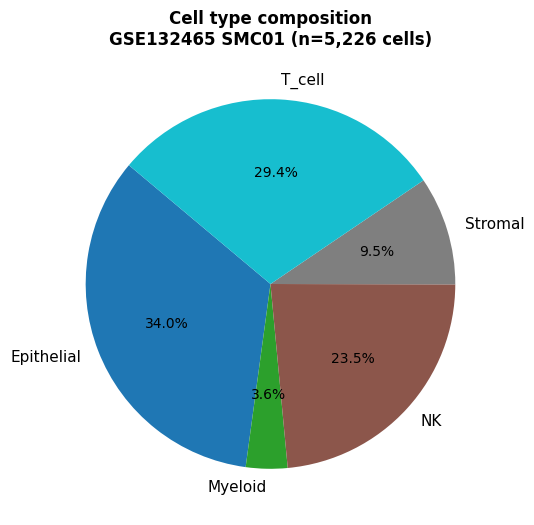

Saved cell_type_composition.png


In [10]:
cell_types_np = cell_types.cpu().numpy()
counts = [int((cell_types_np == i).sum()) for i in range(len(type_names))]
pcts   = [c / sum(counts) * 100 for c in counts]

fig, ax = plt.subplots(figsize=(6, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(type_names)))
wedges, texts, autotexts = ax.pie(
    counts, labels=type_names, autopct='%1.1f%%',
    colors=colors, startangle=140,
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontsize(10)
ax.set_title("Cell type composition\nGSE132465 SMC01 (n=5,226 cells)",
             fontsize=12, fontweight="bold")
fig.savefig(DATA_DIR / "cell_type_composition.png",
            dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved cell_type_composition.png")

In [9]:
red = umap.UMAP(n_components=2, random_state=SEED, min_dist=0.2)
emb_c = red.fit_transform(hC)
emb_b = umap.UMAP(n_components=2, random_state=SEED, min_dist=0.2).fit_transform(hB)

fig, ax = plt.subplots(figsize=(6, 5))
scatter_plot = ax.scatter(emb_c[:, 0], emb_c[:, 1], s=2, c=cell_types.cpu().numpy(), cmap="tab10", alpha=0.7)
ax.set_title("Cell embedding UMAP (colored by cell_type idx)")
fig.colorbar(scatter_plot, ax=ax, fraction=0.046, pad=0.04)
fig.savefig(DATA_DIR / "cell_umap_emb.png", dpi=200, bbox_inches="tight")
plt.close(fig)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(emb_b[:, 0], emb_b[:, 1], c=labels.cpu().numpy(), cmap="coolwarm", s=20, alpha=0.85)
ax.set_title("Bulk embedding UMAP (MSI=1 red)")
fig.savefig(DATA_DIR / "bulk_umap_emb.png", dpi=200, bbox_inches="tight")
plt.close(fig)
print("Saved figures to", DATA_DIR)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved figures to /content/drive/MyDrive/BulkCellGNN_data
